In [109]:
%load_ext autoreload
%autoreload 2
    
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import os
import json
from PIL import Image, ImageDraw
from tqdm import tqdm
from typing import List
import mercury as mr
import cv2
from pathlib import Path
from scipy.ndimage import sobel, laplace, binary_erosion, binary_fill_holes, label, distance_transform_edt
from skimage.feature import graycomatrix, graycoprops

from MirrorFeatureExtractor.mirror_feature_extractor import (
    new_extract_glcm_features,
    new_extract_edge_features,
    new_extract_lbp_features
)

from MirrorExtractor.simple_mirror_extractor import SimpleMirrorExtractor

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [83]:
def build_mask(gray, thr=0):
    m = gray > thr
    m = binary_fill_holes(m)                 # ciemny piksel wewnątrz lustra wraca
    lab, n = label(m)
    if n > 1:                                # zostaw największy spójny obszar
        sizes = np.bincount(lab.ravel()); sizes[0] = 0
        m = lab == sizes.argmax()
    return m

def photometric(gray, m):
    v = gray[m].astype(np.float64)
    med = np.median(v)
    mad = np.median(np.abs(v - med))
    p05, p25, p75, p95 = np.percentile(v, [5, 25, 75, 95])
    return {
        'median':     med,
        'cov':        v.std() / (v.mean() + 1e-8),
        'robust_cov': 1.4826 * mad / (med + 1e-8),
        'iqr_norm':   (p75 - p25) / (med + 1e-8),
        'rng_norm':   (p95 - p05) / (med + 1e-8),
        'sat_frac':   float((v >= 250).mean()),   # FLAGA, nie cecha
    }

def extract_edge_features(gray_img, mask):
    """Extract edge and gradient features using Sobel, Laplacian, and Canny.

    Args:
        gray_img: 2D array, grayscale mirror patch.
        mask: 2D bool array, True inside the mirror facet.

    Returns:
        dict: Feature name -> float value. On failure, all values are np.nan.
    """
    feature_names = ['sobel_mean', 'laplacian_mean', 'laplacian_std', 'edge_density']
    features = {n: np.nan for n in feature_names}

    try:
        # piksele, których całe sąsiedztwo 3x3 leży wewnątrz lustra
        core = binary_erosion(mask, np.ones((3, 3), bool))
        if core.sum() < 10:
            # logging.warning("Mask core too small after erosion")
            print("Mask core too small after erosion")
            return features

        # tło <- najbliższa wartość z wnętrza maski (brak sztucznego skoku 0->200)
        idx = distance_transform_edt(~mask, return_distances=False, return_indices=True)
        g = gray_img[tuple(idx)].astype(np.float64)

        sx, sy = sobel(g, axis=1), sobel(g, axis=0)
        features['sobel_mean'] = np.sqrt(sx**2 + sy**2)[core].mean()

        lap = np.abs(laplace(g))
        features['laplacian_mean'] = lap[core].mean()
        features['laplacian_std'] = lap[core].std()

        edges = cv2.Canny(g.astype(np.uint8), 50, 150)
        features['edge_density'] = (edges[core] > 0).sum() / core.sum()

    except Exception as e:
        #logging.warning(f"Edge feature extraction failed: {e}")
        print(f"Edge feature extraction failed: {e}")
        for n in feature_names:
            features[n] = np.nan

    return features

def extract_mirrors_from_img_series(img_path_list, m_id):
    crop_list = []
    for img_path in img_path_list:
        img = cv2.imread(str(img_path))
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        crop = mirror_extractor.extract_mirror_gray(img_gray, mirror_id=m_id)
        crop_list.append(crop)
    return crop_list
    


In [3]:
img_path = "/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/webcam_img/image_2023-04-23_1400.jpg"

img = cv2.imread(str(img_path))
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mirror_extractor = SimpleMirrorExtractor("/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/calibration/points_WebCam.json")
#mirror_extractor = SimpleMirrorExtractor("/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/points_IRCam.json")

In [31]:
! ls /home/pgliwny/Praca/Computer_vision_for_MAGIC/data/webcam_useful_image/

webcam_useful_images


In [42]:
img_path_list = Path("/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/webcam_useful_image/webcam_useful_images/")
# [p for p in img_path_list.glob("*2024-05-2*.jpg")]
crop_list = extract_mirrors_from_img_serie(img_path_list.glob("*2024-05-2*.jpg"), 15)

In [45]:
print(len(crop_list))
crop_list[0].shape

23


(18, 18)

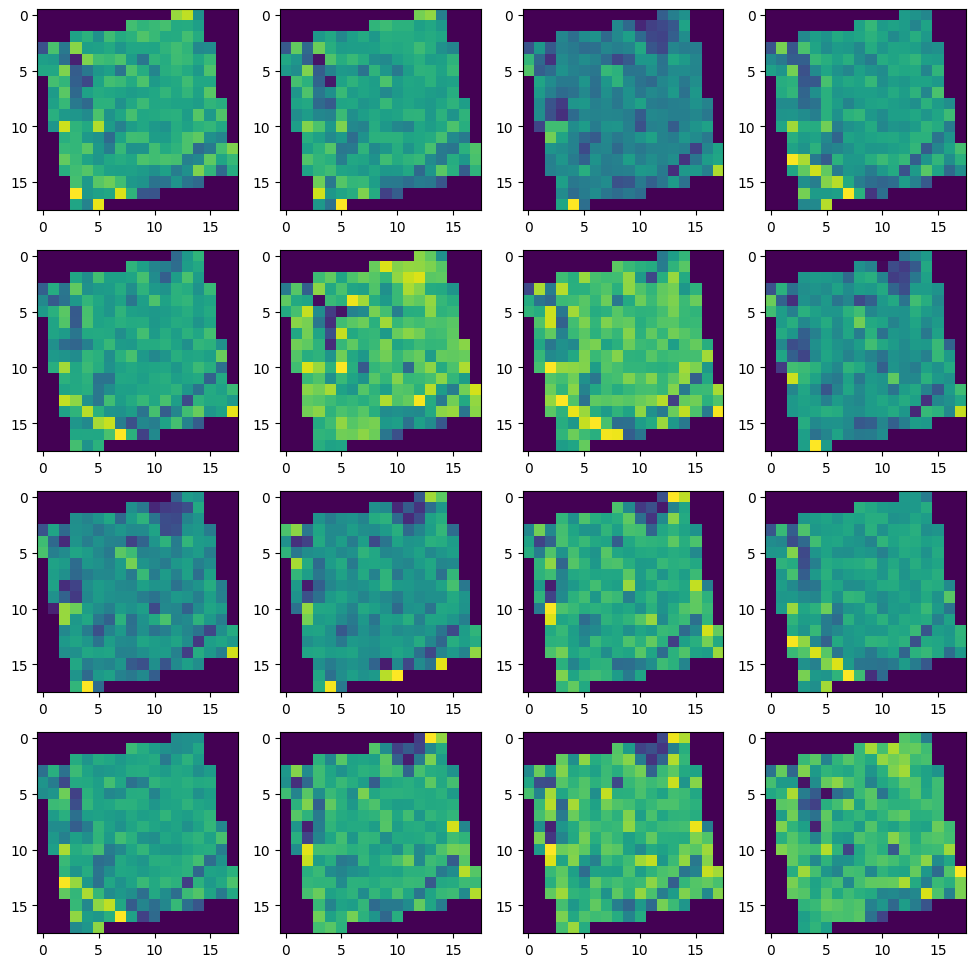

In [47]:
fig, ax = plt.subplots(4, 4, figsize=(12, 12))
axes = ax.flatten()
for i in range(16):
    axes[i].imshow(crop_list[i])
    
plt.show()

In [110]:
rows = []
for i in range(16):
    m_full = build_mask(crop_list[i])
    m_core = binary_erosion(m_full, np.ones((3, 3), bool))
    mask = crop_list[i] > 0
    row = {"id":i}
    ph_output = photometric(crop_list[i], mask)
    edge_output = new_extract_edge_features(crop_list[i], mask)
    glcm_output = new_extract_glcm_features(crop_list[i], mask)
    lbp_output = new_extract_lbp_features(crop_list[i], mask)
    row.update(ph_output)
    row.update(edge_output)
    row.update(glcm_output)
    row.update(lbp_output)
    rows.append(row)

df = pd.DataFrame(rows)
df.keys()

Index(['id', 'median', 'cov', 'robust_cov', 'iqr_norm', 'rng_norm', 'sat_frac',
       'sobel_mean', 'laplacian_mean', 'laplacian_std', 'edge_density',
       'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity',
       'glcm_energy', 'glcm_correlation', 'lbp_entropy', 'lbp_nonuniform'],
      dtype='object')

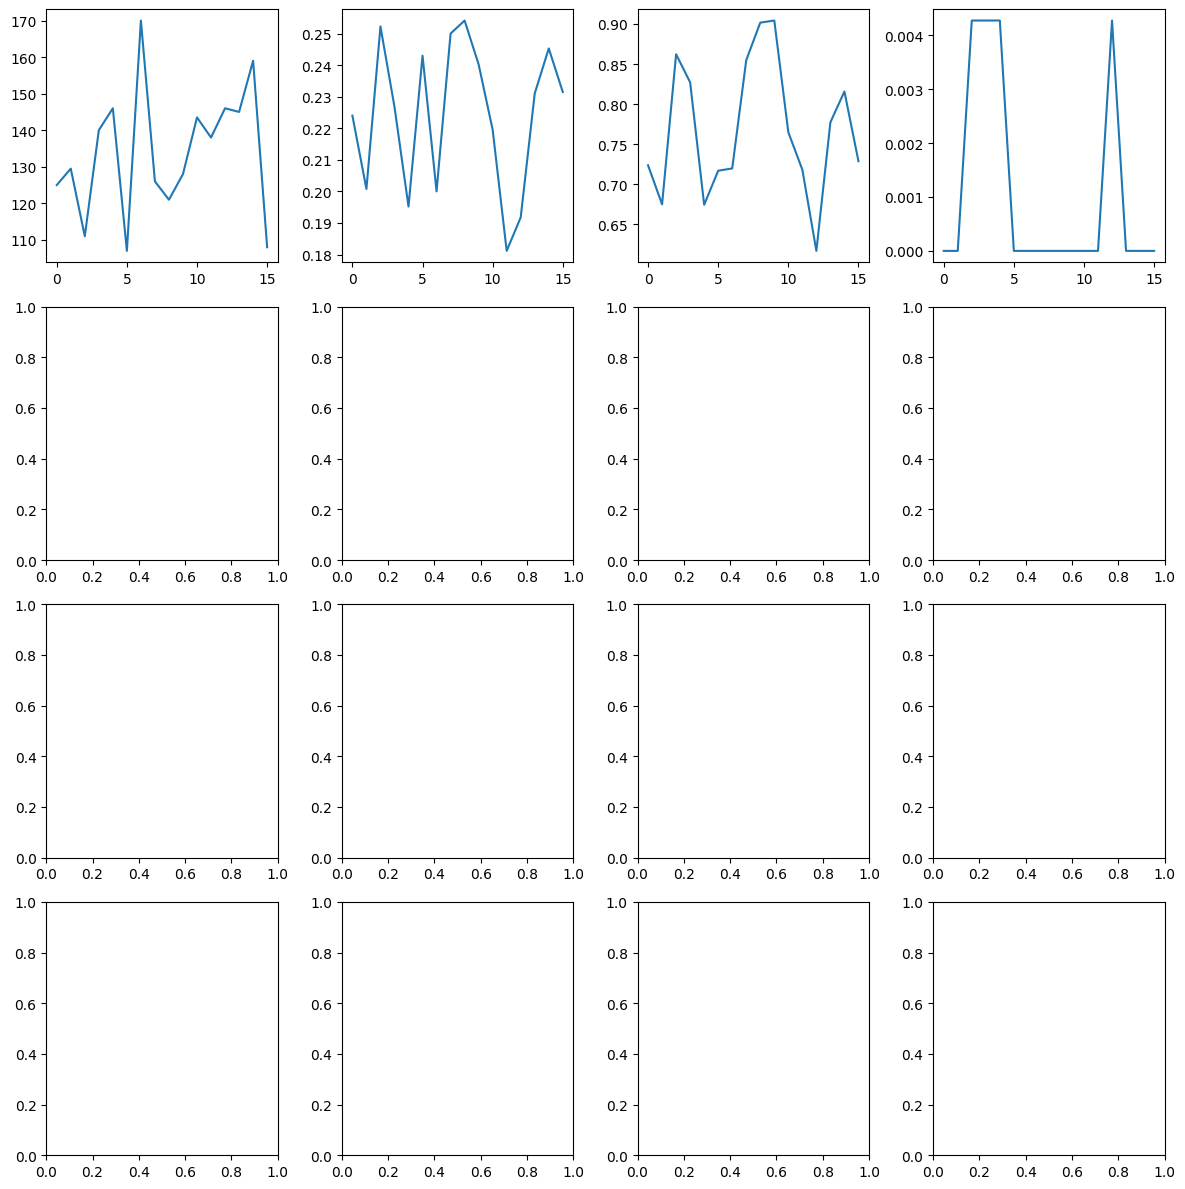

In [111]:
fig, ax = plt.subplots(4, 4, figsize=(12, 12))
axes = ax.flatten()
axes[0].plot(df["median"])
axes[1].plot(df["iqr_norm"])
axes[2].plot(df["rng_norm"])
axes[3].plot(df["sat_frac"])

plt.tight_layout()
plt.show()

In [96]:
# Sobel_mean skaluje się z jasnością — jaśniejsza scena to większe gradienty. 
s = df['sobel_mean'] / df['median']
med = s.median()
rel_mad = (s - med).abs().median() / med
rel_mad

np.float64(0.09492035733541966)

<Axes: >

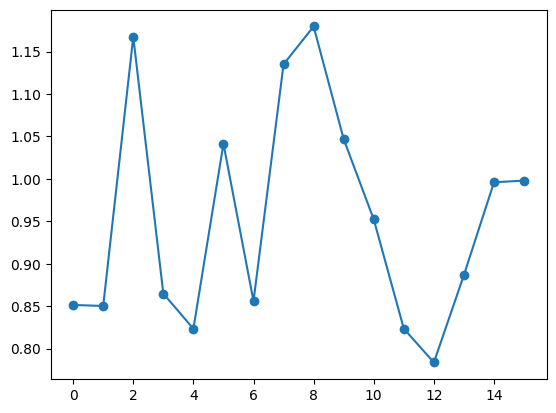

In [98]:
s.plot(marker='o')

In [97]:
cv_sobel = df['sobel_mean'].std()/df['sobel_mean'].mean()
print(cv_sobel)

0.12445989355690064


In [13]:
crop.shape

(18, 16)

In [19]:
m_full = build_mask(crop)
m_core = binary_erosion(m_full, np.ones((3, 3), bool))
print(m_full.sum(), m_core.sum())


228 164


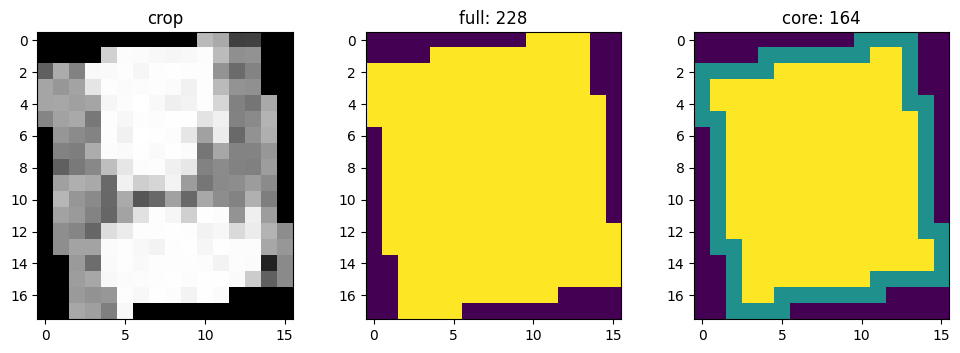

In [49]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3.5))
ax[0].imshow(crop, cmap='gray', vmin=0, vmax=255); ax[0].set_title('crop')
ax[1].imshow(m_full);                              ax[1].set_title(f'full: {m_full.sum()}')
ax[2].imshow(m_full.astype(int) + m_core);         ax[2].set_title(f'core: {m_core.sum()}')
plt.tight_layout()

## Compare to reference 

In [113]:
def _flatten_norm(patch, mask):
    v = patch[mask].astype(np.float64)
    v -= v.mean()
    n = np.linalg.norm(v)
    return v, n


def extract_reference_features(gray_img, mask, bank, min_norm=1e-6):
    """Compare the patch against a memory bank of previously seen patches.

    Normalised cross-correlation is invariant to affine brightness changes,
    so illumination drift does not move it. A defocused facet loses its
    contrast pattern entirely, so its correlation with ANY structured
    reference collapses towards zero, regardless of what the bank contains.

    Using the MAXIMUM over the bank rather than a mean prototype handles the
    multimodal nature of normal appearance: the facet legitimately looks very
    different under clear sky, overcast, and different pointings, and a single
    averaged prototype would match none of them well.

    Features:
        - ncc_max: Best correlation against the bank. Falls sharply when the
          reflection pattern changes or vanishes.
        - ncc_med: Median correlation. Lower ncc_med with high ncc_max means
          the current conditions are rare in the bank, not that the mirror
          changed.
        - resid_rms: RMS residual against the best match, normalised by that
          match's contrast. Catches localised changes that NCC averages away.

    The bank must cover the range of normal appearance. A low ncc_max on a
    sparse bank means "unseen conditions", not "anomaly" - treat bank coverage
    as a prerequisite, and log the bank size alongside the features.

    Args:
        gray_img: 2D array, cropped grayscale patch.
        mask: 2D bool array, True inside the facet.
        bank: 3D array (n_ref, H, W) of reference patches for this facet,
            same shape and same mask as gray_img.

    Returns:
        dict: Feature name -> float. All np.nan on failure.
    """
    features = {'ncc_max': np.nan, 'ncc_med': np.nan, 'resid_rms': np.nan}

    try:
        v, nv = _flatten_norm(gray_img, mask)
        if nv < min_norm or len(bank) == 0:
            logging.warning("Reference: flat patch or empty bank")
            return features

        nccs, refs = [], []
        for ref in bank:
            r, nr = _flatten_norm(ref, mask)
            if nr < min_norm:
                continue
            nccs.append(float(v @ r / (nv * nr)))
            refs.append((r, nr))

        if not nccs:
            return features

        best = int(np.argmax(nccs))
        r, nr = refs[best]
        scale = (v @ r) / (nr ** 2)          # least-squares brightness match

        features['ncc_max'] = float(np.max(nccs))
        features['ncc_med'] = float(np.median(nccs))
        features['resid_rms'] = float(np.linalg.norm(v - scale * r) / (nv + 1e-8))

    except Exception as e:
        logging.warning(f"Reference feature extraction failed: {e}")

    return features

In [114]:
len(crop_list)

23

In [117]:
crop_array = np.array(crop_list)[:, :, :]

In [118]:
m = build_mask(crop_array[16, :, :])
extract_reference_features(crop_array[16, :, :], m, crop_array[:15, :, :], min_norm=1e-6)

{'ncc_max': 0.9446936429433647,
 'ncc_med': 0.6177458515398471,
 'resid_rms': 0.3279541446269945}

In [123]:
vals = [extract_reference_features(c, m, crop_array[:15, :, :])['ncc_max'] for c in crop_list]
print(np.percentile(vals, [1, 5, 50, 95]))

[0.80793608 0.82181324 1.         1.        ]


In [122]:
vals

[{'ncc_max': 1.0000000000000002,
  'ncc_med': 0.4681346488479536,
  'resid_rms': 2.192357786668028e-16},
 {'ncc_max': 1.0, 'ncc_med': 0.4108602923623165, 'resid_rms': 0.0},
 {'ncc_max': 1.0, 'ncc_med': 0.36570210689484506, 'resid_rms': 0.0},
 {'ncc_max': 1.0, 'ncc_med': 0.513571839191863, 'resid_rms': 0.0},
 {'ncc_max': 1.0, 'ncc_med': 0.5882305022453764, 'resid_rms': 0.0},
 {'ncc_max': 1.0, 'ncc_med': 0.19996111798003158, 'resid_rms': 0.0},
 {'ncc_max': 1.0, 'ncc_med': 0.6416532594412421, 'resid_rms': 0.0},
 {'ncc_max': 1.0000000000000002,
  'ncc_med': 0.38936421036930274,
  'resid_rms': 2.2616029530584636e-16},
 {'ncc_max': 1.0, 'ncc_med': 0.42553497323913875, 'resid_rms': 0.0},
 {'ncc_max': 1.0, 'ncc_med': 0.3393013409536362, 'resid_rms': 0.0},
 {'ncc_max': 0.9999999999999998,
  'ncc_med': 0.6155134264823007,
  'resid_rms': 2.15458687839928e-16},
 {'ncc_max': 1.0000000000000002,
  'ncc_med': 0.4704504727303398,
  'resid_rms': 2.2168151907781993e-16},
 {'ncc_max': 0.9999999999999999,